[ 1] 1-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 2.03e-04 | maximum = 0.0002188 | nonzero cells = 52
[ 2] 2-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 3.20e-04 | maximum = 0.0001797 | nonzero cells = 58
[ 3] 3-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 2.50e-04 | maximum = 0.0002344 | nonzero cells = 120
[ 4] 4-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 3.44e-04 | maximum = 0.0002344 | nonzero cells = 72
[ 5] 5-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 2.34e-04 | maximum = 0.0001797 | nonzero cells = 128
[ 6] 6-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 2.97e-04 | maximum = 0.0003203 | nonzero cells = 108
[ 7] 7-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 3.20e-04 | maximum = 0.0002383 | nonzero cells = 120
[ 8] 8-Residue_Residue_5A_Matrix.csv          16 × 16 | asymmetry before = 3.67e-04 | maximum = 0.0001836 |

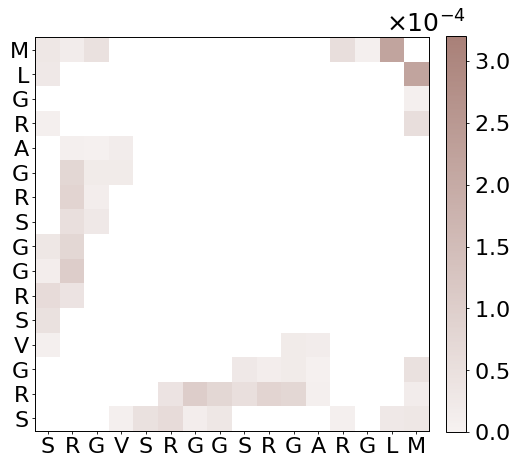

Saved PNG: contact_map_plots/fragment_02_contact_map.png
Saved PDF: contact_map_plots/fragment_02_contact_map.pdf
Saved SVG: contact_map_plots/fragment_02_contact_map.svg


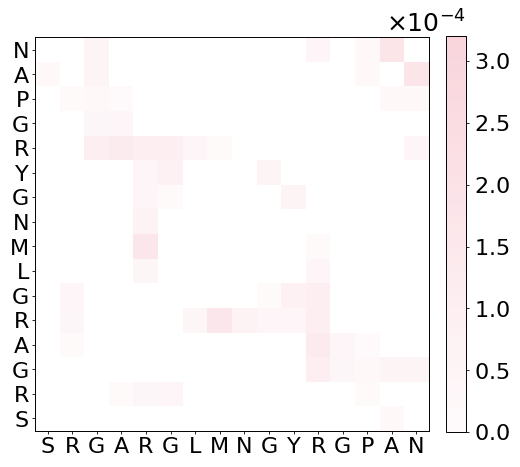

Saved PNG: contact_map_plots/fragment_03_contact_map.png
Saved PDF: contact_map_plots/fragment_03_contact_map.pdf
Saved SVG: contact_map_plots/fragment_03_contact_map.svg


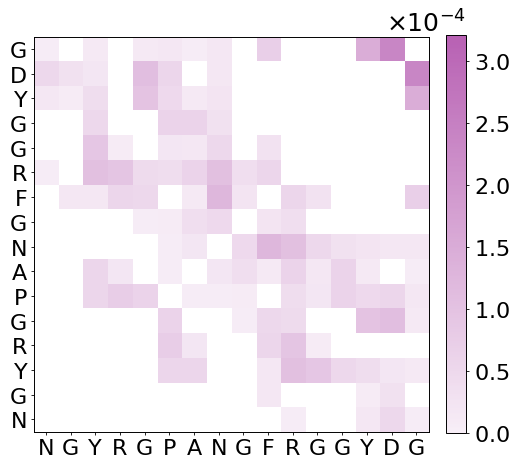

Saved PNG: contact_map_plots/fragment_04_contact_map.png
Saved PDF: contact_map_plots/fragment_04_contact_map.pdf
Saved SVG: contact_map_plots/fragment_04_contact_map.svg


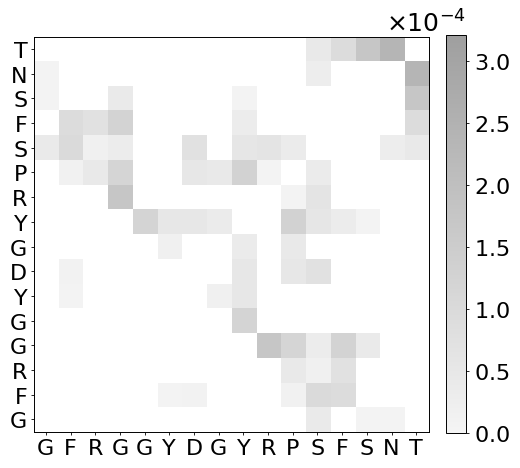

Saved PNG: contact_map_plots/fragment_05_contact_map.png
Saved PDF: contact_map_plots/fragment_05_contact_map.pdf
Saved SVG: contact_map_plots/fragment_05_contact_map.svg


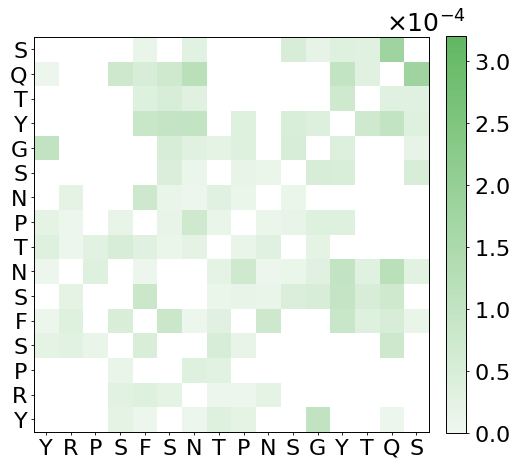

Saved PNG: contact_map_plots/fragment_06_contact_map.png
Saved PDF: contact_map_plots/fragment_06_contact_map.pdf
Saved SVG: contact_map_plots/fragment_06_contact_map.svg


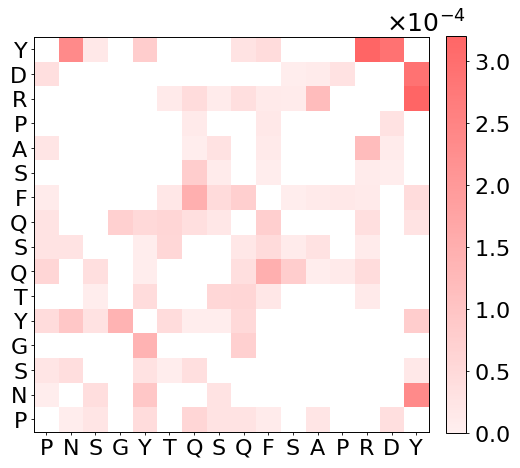

Saved PNG: contact_map_plots/fragment_07_contact_map.png
Saved PDF: contact_map_plots/fragment_07_contact_map.pdf
Saved SVG: contact_map_plots/fragment_07_contact_map.svg


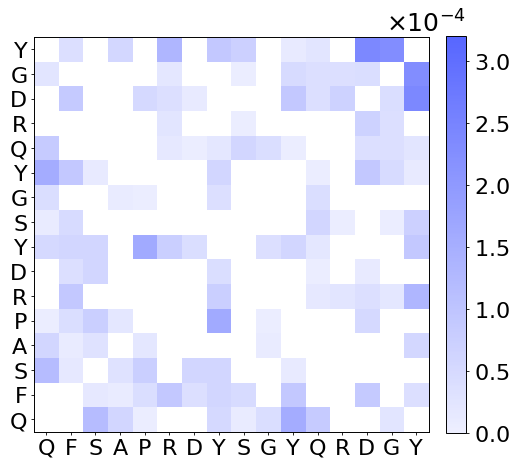

Saved PNG: contact_map_plots/fragment_08_contact_map.png
Saved PDF: contact_map_plots/fragment_08_contact_map.pdf
Saved SVG: contact_map_plots/fragment_08_contact_map.svg


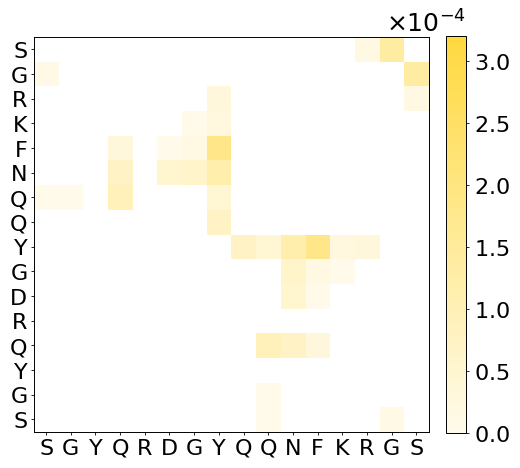

Saved PNG: contact_map_plots/fragment_09_contact_map.png
Saved PDF: contact_map_plots/fragment_09_contact_map.pdf
Saved SVG: contact_map_plots/fragment_09_contact_map.svg


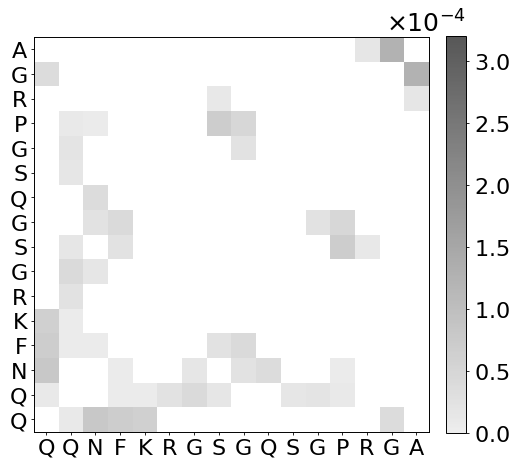

Saved PNG: contact_map_plots/fragment_10_contact_map.png
Saved PDF: contact_map_plots/fragment_10_contact_map.pdf
Saved SVG: contact_map_plots/fragment_10_contact_map.svg


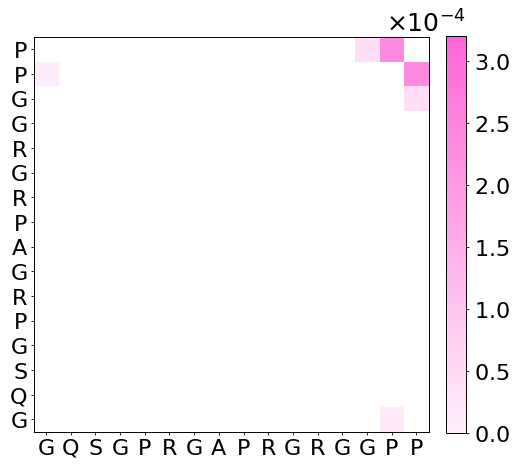

Saved PNG: contact_map_plots/fragment_11_contact_map.png
Saved PDF: contact_map_plots/fragment_11_contact_map.pdf
Saved SVG: contact_map_plots/fragment_11_contact_map.svg


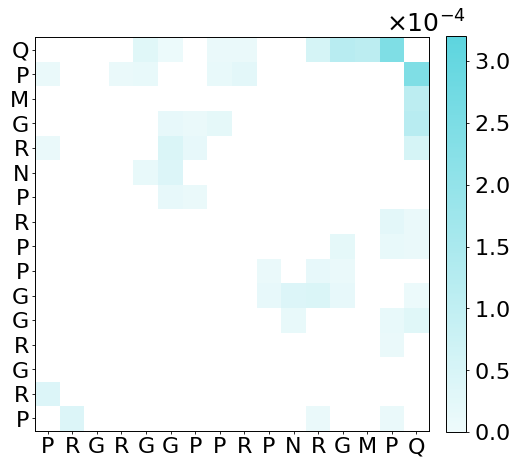

Saved PNG: contact_map_plots/fragment_12_contact_map.png
Saved PDF: contact_map_plots/fragment_12_contact_map.pdf
Saved SVG: contact_map_plots/fragment_12_contact_map.svg


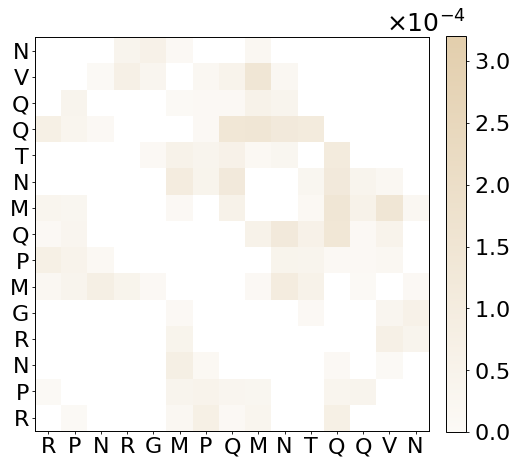

In [10]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter


# CONFIGURATION ======================================================================


DIR             = Path("Extreme")
FILENAME        = "{fid}-Residue_Residue_5A_Matrix.csv"
N_FRAGMENTS     = 12

SYMMETRIZE      = "mean"       
ZERO_DIAGONAL   = True
MASK_ZERO_VALUES = True       # zero values appear white
SHARED_SCALE    = True        # same color scale for all fragments

OUT_DIR         = Path("contact_map_plots")

DPI             = 600
SAVE_PDF        = True
SAVE_SVG        = True

# Lighter color map
FRAGMENT_COLORS = {
    1:  "#8c564b",  # brown
    2:  "#f7c6d0",  # light pink
    3:  "#a02c9a",  # purple
    4:  "#7f7f7f",  # gray
    5:  "#2ca02c",  # green
    6:  "#ff3333",  # red
    7:  "#1f33ff",  # blue
    8:  "#ffcc00",  # yellow
    9:  "#1f1f1f",  # black
    10: "#ff33cc",  # magenta
    11: "#27c7d4",  # cyan
    12: "#d9be91",  # beige
}
CMAP_MIN        = 0.08
CMAP_MAX        = 0.75

# Use 100 to preserve the actual maximum.
VMAX_PERCENTILE = 100.0


three_to_one = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


# PUBLICATION STYLE # ======================================================================


PUBLICATION_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # Editable text in vector files
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
}


def make_light_colormap(
    fragment_id,
    lower=CMAP_MIN,
    upper=CMAP_MAX,
):
    """Create a lighter truncated Matplotlib colormap."""

    base_color = FRAGMENT_COLORS[fragment_id]

    base = LinearSegmentedColormap.from_list(
        f"fragment_{fragment_id}_base",
        ["white", base_color],
        N=256,
    )

    colors = base(np.linspace(lower, upper, 256))

    cmap = LinearSegmentedColormap.from_list(
        f"fragment_{fragment_id}_light",
        colors,
        N=256,
    )

    cmap.set_bad("white")
    cmap.set_under("white")

    return cmap


#  
# READ MATRICES ======================================================================
 
def read_matrix(csv_path: Path) -> pd.DataFrame:
    """Read a square contact matrix with residue labels."""

    df = pd.read_csv(csv_path)
    df.columns = df.columns.astype(str).str.strip()

    source_cols = [
        column
        for column in df.columns
        if column.lower() in {
            "source_residue",
            "source",
            "residue",
            "res_i",
            "residue_i",
        }
    ]

    if source_cols:
        labels = df[source_cols[0]].astype(str).str.strip()
        matrix = df.drop(columns=source_cols)

        columns_to_drop = []

        for column in matrix.columns:
            column_name = str(column)

            if column_name.lower().startswith("unnamed"):
                columns_to_drop.append(column)
                continue

            numeric_values = pd.to_numeric(
                matrix[column],
                errors="coerce",
            )

            # Remove a pure 1, 2, ..., n index column
            if numeric_values.notna().all():
                values = numeric_values.to_numpy()

                if np.allclose(
                    values,
                    np.arange(1, len(matrix) + 1),
                ):
                    columns_to_drop.append(column)

        matrix = matrix.drop(columns=columns_to_drop)
        matrix.index = labels

    else:
        matrix = pd.read_csv(csv_path, index_col=0)
        matrix.index = matrix.index.astype(str).str.strip()

    # Remove remaining unnamed columns
    keep_columns = (
        ~matrix.columns.astype(str)
        .str.lower()
        .str.startswith("unnamed")
    )

    matrix = matrix.loc[:, keep_columns]
    matrix.columns = matrix.columns.astype(str).str.strip()

    matrix = matrix.apply(
        pd.to_numeric,
        errors="coerce",
    ).fillna(0.0)

    return matrix


def symmetrize(
    matrix: pd.DataFrame,
    mode="mean",
    zero_diag=True,
) -> np.ndarray:
    """Create a symmetric contact matrix."""

    array = matrix.to_numpy(dtype=float)

    if mode == "mean":
        array = 0.5 * (array + array.T)

    elif mode == "max":
        array = np.maximum(array, array.T)

    else:
        raise ValueError(
            'SYMMETRIZE must be either "mean" or "max".'
        )

    if zero_diag:
        np.fill_diagonal(array, 0.0)

    return array


def residue_letter_labels(labels) -> list[str]:
    """
    Convert labels to one-letter residue names without residue numbers.

    Examples:
        ARG1  -> R
        SER9  -> S
        ALA15 -> A
    """

    output = []

    for label in labels:
        text = str(label).strip()

        residue_match = re.match(
            r"\s*([A-Za-z]{3})",
            text,
        )

        if residue_match:
            residue_code = residue_match.group(1).upper()
            one_letter = three_to_one.get(residue_code, "?")
        else:
            one_letter = "?"

        output.append(one_letter)

    return output


def load_all() -> dict:
    """Load all available fragment contact matrices."""

    fragments = {}

    for fragment_id in range(1, N_FRAGMENTS + 1):

        csv_path = DIR / FILENAME.format(fid=fragment_id)

        if not csv_path.exists():
            print(f"[{fragment_id:>2}] Missing: {csv_path}")
            continue

        matrix = read_matrix(csv_path)

        if matrix.shape[0] != matrix.shape[1]:
            print(
                f"[{fragment_id:>2}] Skipped: "
                f"non-square matrix {matrix.shape}"
            )
            continue

        raw_array = matrix.to_numpy(dtype=float)

        asymmetry = float(
            np.max(np.abs(raw_array - raw_array.T))
        )

        contact_array = symmetrize(
            matrix,
            mode=SYMMETRIZE,
            zero_diag=ZERO_DIAGONAL,
        )

        if not np.allclose(contact_array, contact_array.T):
            raise ValueError(
                f"Fragment {fragment_id} is not symmetric."
            )

        labels = residue_letter_labels(matrix.index)

        fragments[fragment_id] = (
            contact_array,
            labels,
        )

        print(
            f"[{fragment_id:>2}] "
            f"{csv_path.name:<40} "
            f"{contact_array.shape[0]} × "
            f"{contact_array.shape[1]} | "
            f"asymmetry before = {asymmetry:.2e} | "
            f"maximum = {contact_array.max():.4g} | "
            f"nonzero cells = {int(np.sum(contact_array > 0))}"
        )

    return fragments


# ======================================================================
# COLOR NORMALIZATION
# ======================================================================

def calculate_shared_vmax(fragments: dict) -> float:
    """Calculate one common upper color limit for every fragment."""

    positive_values = []

    for array, _ in fragments.values():
        values = array[array > 0]

        if values.size > 0:
            positive_values.append(values)

    if not positive_values:
        return 1.0

    all_values = np.concatenate(positive_values)

    vmax = float(
        np.percentile(
            all_values,
            VMAX_PERCENTILE,
        )
    )

    if not np.isfinite(vmax) or vmax <= 0:
        vmax = float(np.max(all_values))

    return max(vmax, 1e-12)


def prepare_for_display(array: np.ndarray):
    """Mask zero-contact values so they appear white."""

    display_array = np.asarray(array, dtype=float)

    if MASK_ZERO_VALUES:
        display_array = np.ma.masked_less_equal(
            display_array,
            0.0,
        )

    return display_array


def format_colorbar(colorbar):
    """Format color-bar labels using scientific notation when needed."""

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))

    colorbar.formatter = formatter
    colorbar.update_ticks()

    colorbar.ax.tick_params(
        labelsize=16,
        width=0.6,
        length=2.5,
    )

    colorbar.outline.set_linewidth(0.7)
    colorbar.ax.yaxis.get_offset_text().set_fontsize(18)


# ======================================================================
# SAVE EACH FRAGMENT SEPARATELY
# ======================================================================

def plot_individual_fragments(
    fragments: dict,
    out_dir=OUT_DIR,
):
    """Save one separate publication-quality plot per fragment."""

    if not fragments:
        raise SystemExit(
            f"No fragment matrices found in {DIR.resolve()}."
        )

    out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    shared_vmax = (
        calculate_shared_vmax(fragments)
        if SHARED_SCALE
        else None
    )

    with mpl.rc_context(PUBLICATION_RC):

        for fragment_id, (array, labels) in sorted(
            fragments.items()
        ):

            cmap = make_light_colormap(fragment_id)

            if SHARED_SCALE:
                vmax = shared_vmax
            else:
                positive_values = array[array > 0]

                if positive_values.size:
                    vmax = float(
                        np.percentile(
                            positive_values,
                            VMAX_PERCENTILE,
                        )
                    )
                else:
                    vmax = 1.0

            norm = Normalize(
                vmin=0.0,
                vmax=max(vmax, 1e-12),
            )

            display_array = prepare_for_display(array)

            fig, ax = plt.subplots(
                figsize=(5.2, 4.8)
            )

            image = ax.imshow(
                display_array,
                cmap=cmap,
                norm=norm,
                interpolation="none",
                origin="lower",
                aspect="equal",
                rasterized=True,
            )

            number_of_residues = len(labels)
            positions = np.arange(number_of_residues)

            ax.set_xticks(positions)
            ax.set_yticks(positions)

            # Residue letters only: R, S, A, etc.
            ax.set_xticklabels(
                labels,
                rotation=0,
                ha="center",
            )

            ax.set_yticklabels(labels)

            ax.tick_params(
                axis="both",
                which="major",
                direction="out",
                pad=2,
            )

            # ax.set_xlabel("Residue")
            # ax.set_ylabel("Residue")

            # ax.set_title(
            #     f"Fragment {fragment_id}",
            #     fontweight="semibold",
            #     pad=8,
            # )

            ax.set_xlim(
                -0.5,
                number_of_residues - 0.5,
            )

            ax.set_ylim(
                -0.5,
                number_of_residues - 0.5,
            )

            for spine in ax.spines.values():
                spine.set_linewidth(0.7)

            colorbar = fig.colorbar(
                image,
                ax=ax,
                fraction=0.046,
                pad=0.04,
            )

            # colorbar.set_label(
            #     "Symmetrized contact value",
            #     fontsize=9,
            #     labelpad=7,
            # )

            format_colorbar(colorbar)

            fig.tight_layout(pad=0.8)

            output_base = (
                out_dir /
                f"fragment_{fragment_id:02d}_contact_map"
            )

            # High-resolution PNG
            png_path = output_base.with_suffix(".png")

            fig.savefig(
                png_path,
                dpi=DPI,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="white",
            )

            print(f"Saved PNG: {png_path}")

            # Vector PDF
            if SAVE_PDF:
                pdf_path = output_base.with_suffix(".pdf")

                fig.savefig(
                    pdf_path,
                    bbox_inches="tight",
                    facecolor="white",
                    edgecolor="white",
                )

                print(f"Saved PDF: {pdf_path}")

            # Vector SVG
            if SAVE_SVG:
                svg_path = output_base.with_suffix(".svg")

                fig.savefig(
                    svg_path,
                    bbox_inches="tight",
                    facecolor="white",
                    edgecolor="white",
                )

                print(f"Saved SVG: {svg_path}")

            plt.show()
            plt.close(fig)


# ======================================================================
# RUN
# ======================================================================

if __name__ == "__main__":

    fragments = load_all()

    plot_individual_fragments(
        fragments=fragments,
        out_dir=OUT_DIR,
    )